In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("C:\\Users\\LENOVO\\Desktop\\Development-jourey\\machinelearningworks\\algorithms\\unsuperwised_machine_learning\\k_means\\country_data\\Country-data.xls")

In [123]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [124]:
x=df[['child_mort', 'health', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp']]

In [125]:
x.head()

,child_mort,health,income,inflation,life_expec,total_fer,gdpp
0,90.2,7.58,1610,9.44,56.2,5.82,553
1,16.6,6.55,9930,4.49,76.3,1.65,4090
2,27.3,4.17,12900,16.10,76.5,2.89,4460
3,119.0,2.85,5900,22.40,60.1,6.16,3530
4,10.3,6.03,19100,1.44,76.8,2.13,12200


x.

In [126]:
x.columns

Index(['child_mort', 'health', 'income', 'inflation', 'life_expec',
       'total_fer', 'gdpp'],
      dtype='object')

In [127]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x=scaler.fit_transform(x)

In [128]:
x

array([[0.42648491, 0.35860783, 0.00804721, ..., 0.47534517, 0.73659306,
        0.00307343],
       [0.06815969, 0.29459291, 0.07493307, ..., 0.87179487, 0.07886435,
        0.03683341],
       [0.12025316, 0.14667495, 0.0988094 , ..., 0.87573964, 0.27444795,
        0.04036499],
       ...,
       [0.10077897, 0.31261653, 0.03120001, ..., 0.8086785 , 0.12618297,
        0.01029885],
       [0.26144109, 0.20944686, 0.03111961, ..., 0.69822485, 0.55520505,
        0.01029885],
       [0.39191821, 0.25357365, 0.02147261, ..., 0.39250493, 0.670347  ,
        0.01173057]], shape=(167, 7))

In [129]:
from sklearn.cluster import KMeans
wcss=[]

for i in range(1,11):

    km= KMeans(random_state=1,n_clusters=i)
    km.fit(x)
    wcss.append(km.inertia_)

print(wcss)    

[36.4609501831829, 19.939773827274, 13.43824085543626, 11.657707136175674, 10.172179681781419, 9.667280784579177, 8.845896172940833, 8.316091265733506, 7.493368917987883, 6.923777296859683]


([<matplotlib.axis.XTick at 0x26ee85a5d10>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

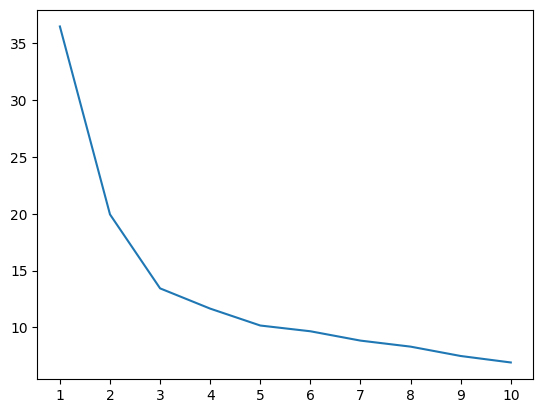

In [130]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))

In [131]:
kms = KMeans(random_state=1,n_clusters=3)
y=kms.fit_predict(x)
y

array([2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 0,
       1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 1, 0, 1, 2, 0, 1, 1, 0, 0, 2, 0, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2], dtype=int32)

In [132]:
from sklearn.metrics import silhouette_score
print(silhouette_score(x,y))

0.4039322494167937


In [133]:
df["countr_devloping_status"]=y

In [134]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,countr_devloping_status
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [135]:
df[df["country"]=="India"]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,countr_devloping_status
69,India,58.8,22.6,4.05,27.1,4410,8.98,66.2,2.6,1350,0
